<a href="https://colab.research.google.com/github/fahadahmad84-design/Quantum-Computing-Labs/blob/main/notebooks/Week_01_First_Quantum_Circuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Laboratory: Your First Quantum Circuit

**M34099 Quantum Computing · Level 7 · 2026/27 · LO1 and LO2**

## Why this laboratory matters

This laboratory turns the Week 1 ideas into evidence. You will represent basis states, calculate probabilities from amplitudes, check normalisation, create a Hadamard superposition and measure a circuit repeatedly. You will first use an ideal simulator and then, if your IBM Quantum Classroom access is active, run the same experiment on a real quantum computer.

## Learning outcomes

By the end of this laboratory, you should be able to:

1. represent $|0\rangle$ and $|1\rangle$ as column vectors;
2. calculate $P(0)=|\alpha|^2$ and $P(1)=|\beta|^2$;
3. verify that a one-qubit state is normalised;
4. build, draw and simulate a one-qubit Qiskit circuit;
5. distinguish theoretical probability from observed frequency; and
6. compare an ideal simulation with results from real IBM quantum hardware.

## Laboratory rule

**Predict → Build → Inspect → Run → Explain.** Do not use the notebook as a replacement for reasoning. Write down your prediction before executing a circuit.

Official references: [Qiskit documentation](https://quantum.cloud.ibm.com/docs) · [IBM Quantum Learning](https://quantum.cloud.ibm.com/learning)

## Task 0 · Prepare Google Colab

Run the installation cell once. Colab may display a message about restarting the runtime; restart only if requested, then run the cells again from the top.

The packages have different jobs:

- `qiskit` creates and transforms quantum circuits;
- `qiskit-aer` provides the local ideal simulator;
- `qiskit-ibm-runtime` connects to IBM Quantum hardware; and
- `pylatexenc` helps Qiskit draw circuit labels.

In [1]:
# Install the core Qiskit package used to create and transpile quantum circuits.
%pip install -q qiskit
# Install Qiskit Aer, which provides the ideal simulator used in the first part.
%pip install -q qiskit-aer
# Install the IBM Runtime client used later to access classroom hardware.
%pip install -q qiskit-ibm-runtime
# Install LaTeX support so circuit diagrams render correctly in Colab.
%pip install -q pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137

In [2]:
# Import NumPy for vectors, square roots and numerical calculations.
import numpy as np
# Import Matplotlib for displaying comparison charts.
import matplotlib.pyplot as plt
# Import the circuit class and transpiler from Qiskit.
from qiskit import QuantumCircuit, transpile
# Import Statevector so we can inspect a state before measurement.
from qiskit.quantum_info import Statevector
# Import the ideal local simulator.
from qiskit_aer import AerSimulator
# Import Qiskit's histogram plotting function.
from qiskit.visualization import plot_histogram
# Confirm that the imports completed successfully.
print("Environment ready: Qiskit and the simulator are available.")

Environment ready: Qiskit and the simulator are available.


## Task 1 · Represent the computational basis states

In the lecture and mathematics worksheet:

$$|0\rangle=\begin{bmatrix}1\\0\end{bmatrix}, \qquad |1\rangle=\begin{bmatrix}0\\1\end{bmatrix}.$$

### Predict

1. What is the norm of each vector?
2. What measurement outcome is expected from each state?

Run the code only after recording your answers.

In [3]:
# Create the vector representation of the basis state |0>.
ket0 = np.array([1, 0], dtype=complex)
# Create the vector representation of the basis state |1>.
ket1 = np.array([0, 1], dtype=complex)
# Calculate the norm of |0> to check that it has unit length.
norm_ket0 = np.linalg.norm(ket0)
# Calculate the norm of |1> to check that it has unit length.
norm_ket1 = np.linalg.norm(ket1)
# Display the first basis vector and its norm.
print("|0> =", ket0, "  norm =", norm_ket0)
# Display the second basis vector and its norm.
print("|1> =", ket1, "  norm =", norm_ket1)

|0> = [1.+0.j 0.+0.j]   norm = 1.0
|1> = [0.+0.j 1.+0.j]   norm = 1.0


## Task 2 · Convert amplitudes into probabilities

Consider the state used in the lecture and worksheet:

$$|\psi\rangle=0.6|0\rangle+0.8|1\rangle.$$

### Predict

Calculate $P(0)$, $P(1)$ and their sum. Decide whether the state is normalised and which outcome is more likely.

In [4]:
# Store the amplitudes alpha=0.6 and beta=0.8 as a state vector.
psi = np.array([0.6, 0.8], dtype=complex)
# Square the magnitude of alpha to calculate the probability of measuring 0.
p0 = abs(psi[0]) ** 2
# Square the magnitude of beta to calculate the probability of measuring 1.
p1 = abs(psi[1]) ** 2
# Add the probabilities to check the normalisation condition.
probability_total = p0 + p1
# Display the calculated probability of outcome 0.
print("P(0) =", p0)
# Display the calculated probability of outcome 1.
print("P(1) =", p1)
# Display the sum, which must equal 1 for a valid state.
print("P(0) + P(1) =", probability_total)

P(0) = 0.36
P(1) = 0.6400000000000001
P(0) + P(1) = 1.0


### Checkpoint

Write short answers before continuing:

- Is the state normalised? Explain using the numerical result.
- Which outcome is more likely?
- Why does “more likely” not mean “guaranteed” for a single shot?

### Link to the mathematics worksheet

Repeat the calculation for $|\chi\rangle=\frac{1}{2}|0\rangle+\frac{\sqrt{3}}{2}|1\rangle$ before changing the amplitudes in the optional cell below.

In [5]:
# Set alpha to the first amplitude in the guided-practice state.
alpha = 1 / 2
# Set beta to the second amplitude in the guided-practice state.
beta = np.sqrt(3) / 2
# Calculate the probability of measuring 0.
guided_p0 = abs(alpha) ** 2
# Calculate the probability of measuring 1.
guided_p1 = abs(beta) ** 2
# Display both probabilities and their sum for the normalisation check.
print("P(0) =", guided_p0, "P(1) =", guided_p1, "Total =", guided_p0 + guided_p1)

P(0) = 0.25 P(1) = 0.7499999999999999 Total = 0.9999999999999999


## Task 3 · Create a Hadamard superposition

Qiskit places a newly created qubit in $|0\rangle$. Applying a Hadamard gate gives

$$H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}.$$

### Predict

Before running the cell, write down:

- the two amplitudes;
- $P(0)$ and $P(1)$; and
- what one measurement shot could produce.

Statevector: [0.70710678+0.j 0.70710678+0.j]
Probabilities: [0.5 0.5]


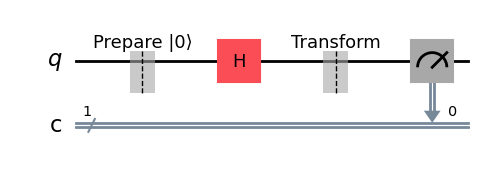

In [19]:
# Create a quantum circuit containing one qubit and no classical bit yet.
qc_h = QuantumCircuit(1,1)
# Prepare State.
qc_h.barrier(label="Prepare |0⟩")
# Apply a Hadamard gate to qubit 0.
qc_h.h(0)
# Apply a Barrier to seperate.
qc_h.barrier(label="Transform")
# Calculate the exact statevector produced by the circuit before measurement.
state_h = Statevector.from_instruction(qc_h)
# Display the complex amplitudes in the order |0>, |1>.
print("Statevector:", state_h.data)
# Display the ideal measurement probabilities derived from those amplitudes.
print("Probabilities:", state_h.probabilities())
# Apply a Measurement.
qc_h.measure(0, 0)
# Draw the circuit so that its time-ordered instruction can be inspected.
qc_h.draw(output="mpl")

### Checkpoint

- Compare the displayed amplitudes with $1/\sqrt{2}$.
- Why do the probabilities not preserve the sign or phase of an amplitude?
- Why is superposition not accurately described as “seeing both answers at once”?

## Task 4 · Measure repeatedly on an ideal simulator

A statevector gives exact amplitudes, but an experiment produces classical outcomes. Repeated runs—called **shots**—estimate the underlying probability distribution.

### Predict

For 1,000 shots of $H|0\rangle$, predict approximate counts for `0` and `1`. Exact equality is not required.

Ideal simulator counts: {'1': 486, '0': 514}


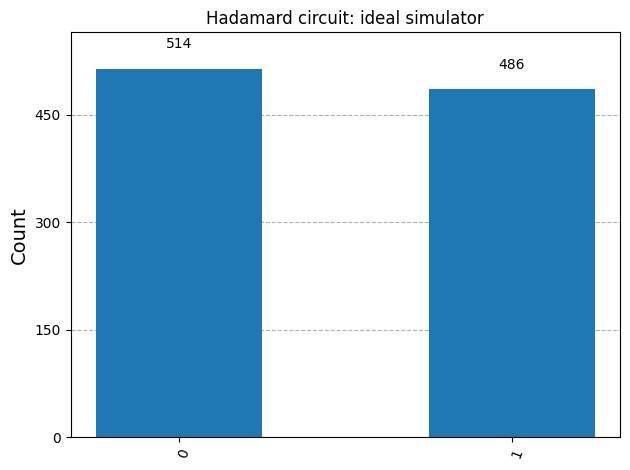

In [7]:
# Create a circuit with one qubit; measure_all will add the classical register.
qc_measure = QuantumCircuit(1)
# Apply a Hadamard gate to prepare an equal superposition.
qc_measure.h(0)
# Measure every qubit and store each outcome in a classical bit.
qc_measure.measure_all()
# Create an ideal Aer simulator with no hardware noise.
simulator = AerSimulator()
# Translate the circuit into instructions supported by the simulator.
compiled_simulator_circuit = transpile(qc_measure, simulator)
# Submit 1,000 repeated shots; the fixed seed makes teaching output reproducible.
simulation_job = simulator.run(compiled_simulator_circuit, shots=1000, seed_simulator=42)
# Retrieve the completed simulation result.
simulation_result = simulation_job.result()
# Extract the number of observed 0 and 1 outcomes.
simulation_counts = simulation_result.get_counts()
# Display the raw counts.
print("Ideal simulator counts:", simulation_counts)
# Plot the counts as a histogram.
plot_histogram(simulation_counts, title="Hadamard circuit: ideal simulator")

In [8]:
# Repeat the experiment for three sample sizes to investigate finite-shot variation.
for number_of_shots in [100, 1000, 10000]:
    # Run the already compiled circuit using the current number of shots.
    shot_job = simulator.run(compiled_simulator_circuit, shots=number_of_shots, seed_simulator=42)
    # Extract the measurement counts from this run.
    shot_counts = shot_job.result().get_counts()
    # Convert the zero count into a relative frequency; use 0 if the key is absent.
    frequency_zero = shot_counts.get("0", 0) / number_of_shots
    # Convert the one count into a relative frequency; use 0 if the key is absent.
    frequency_one = shot_counts.get("1", 0) / number_of_shots
    # Display the sample size, counts and relative frequencies.
    print(number_of_shots, "shots:", shot_counts, "frequencies:", frequency_zero, frequency_one)

100 shots: {'1': 51, '0': 49} frequencies: 0.49 0.51
1000 shots: {'1': 486, '0': 514} frequencies: 0.514 0.486
10000 shots: {'0': 4921, '1': 5079} frequencies: 0.4921 0.5079


### Checkpoint

- Explain the difference between a theoretical probability and an observed relative frequency.
- Do more shots guarantee exact 50/50 counts?
- What generally happens to the relative frequencies as the number of shots increases?

## Task 5 · Independent challenge: test reversibility

Build and test the circuit

$$|0\rangle \rightarrow H \rightarrow H \rightarrow \text{measurement}.$$

### Predict

Use $H^2=I$ to predict the final state and measurement outcome. Then complete the marked lines. Do not copy the Task 4 circuit without explaining each step.

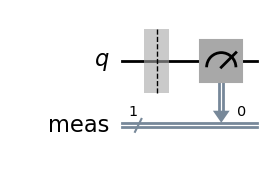

In [9]:
# Create a one-qubit circuit for the double-Hadamard experiment.
qc_double_h = QuantumCircuit(1)
# TODO: Apply the first Hadamard gate to qubit 0.

# TODO: Apply the second Hadamard gate to qubit 0.

# Measure the final qubit in the computational basis.
qc_double_h.measure_all()
# TODO: Transpile qc_double_h for the existing simulator.

# TODO: Run 1,000 shots with seed_simulator=42 and save the job.

# TODO: Retrieve and display the counts from the completed job.

# Draw the completed circuit for inspection.
qc_double_h.draw(output="mpl")

## Task 6 · Run the Hadamard experiment on real IBM quantum hardware

Complete this section only after the tutor confirms that your IBM Quantum Classroom access is active.

### What you need

- your own IBM Cloud API key; and
- the CRN of the classroom instance assigned to you.

### Security rules

1. Never type a credential directly into a visible code cell.
2. Never save an API key or CRN in GitHub.
3. The hidden prompts below keep the values out of the displayed notebook, but credentials exist temporarily in the active Colab session.
4. When finished, use **Runtime → Disconnect and delete runtime** in Colab, especially on a shared computer.

Set the control below to `True` only when you are ready to submit a real hardware job. A real job may wait in a queue.

In [10]:
# Keep this False while completing the simulator activities.
RUN_ON_REAL_HARDWARE = False
# Display the selected execution mode so an accidental submission is less likely.
print("Real-hardware execution enabled:", RUN_ON_REAL_HARDWARE)

Real-hardware execution enabled: False


In [11]:
# Import getpass so credentials can be entered without displaying them.
from getpass import getpass
# Import the IBM service connection and current Sampler V2 interface.
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
# Import the preset pass manager used to map a circuit to a physical device.
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Run the authentication block only when the student has deliberately enabled it.
if RUN_ON_REAL_HARDWARE:
    # Ask for the student's personal IBM Cloud API key using a hidden prompt.
    ibm_api_key = getpass("Paste your IBM Cloud API key (input hidden): ")
    # Ask for the classroom instance CRN using a hidden prompt.
    classroom_crn = getpass("Paste your classroom instance CRN (input hidden): ")
    # Connect this temporary session to the student's assigned classroom instance.
    service = QiskitRuntimeService(channel="ibm_quantum_platform", token=ibm_api_key, instance=classroom_crn)
    # Confirm successful authentication without printing either credential.
    print("Connected to the IBM Quantum classroom instance.")
else:
    # Explain why no credential prompt appeared.
    print("Hardware section skipped. Change RUN_ON_REAL_HARDWARE to True when authorised.")

Hardware section skipped. Change RUN_ON_REAL_HARDWARE to True when authorised.


In [12]:
# Submit a hardware job only when real-hardware mode is enabled.
if RUN_ON_REAL_HARDWARE:
    # Select an operational non-simulator backend that has enough qubits.
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=qc_measure.num_qubits)
    # Display the selected hardware name for the laboratory record.
    print("Selected IBM quantum computer:", backend.name)
    # Build an optimisation-level-1 pass manager for the selected physical device.
    pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)
    # Convert the logical Hadamard circuit into an ISA circuit supported by that device.
    isa_circuit = pass_manager.run(qc_measure)
    # Create a Sampler V2 primitive configured to execute on the selected backend.
    hardware_sampler = SamplerV2(mode=backend)
    # Submit one circuit with 1,000 shots and keep the returned job handle.
    hardware_job = hardware_sampler.run([isa_circuit], shots=1000)
    # Display the job identifier so the run can be traced in IBM Quantum.
    print("IBM job ID:", hardware_job.job_id())
    # Wait for the queued job to finish and retrieve its first published result.
    hardware_result = hardware_job.result()[0]
    # Extract counts from the classical register created by measure_all, named 'meas'.
    hardware_counts = hardware_result.data.meas.get_counts()
    # Display the raw hardware counts.
    print("Real-hardware counts:", hardware_counts)
    # Plot ideal simulation and real-hardware counts on the same axes.
    plot_histogram([simulation_counts, hardware_counts], legend=["Ideal simulator", "IBM hardware"], title="Simulator versus real hardware")
else:
    # Remind the student that the simulator work remains complete without a hardware job.
    print("No hardware job submitted; your simulator results remain available above.")

No hardware job submitted; your simulator results remain available above.


### Hardware comparison record

If you ran the hardware section, record:

- IBM backend name:
- IBM job ID:
- simulator counts:
- hardware counts:
- unexpected outcomes or differences:

Then explain:

1. Why might the real counts differ from the ideal simulation?
2. Does a difference automatically mean that quantum theory is incorrect?
3. Why should a fair comparison use the same logical circuit and number of shots?

If classroom access or the hardware queue prevented execution, record that limitation. Do not fabricate hardware results.

## Extension · Probabilities can hide relative phase

The states

$$|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}, \qquad |-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}$$

have identical computational-basis probabilities. Predict what happens when a Hadamard gate is applied to each state.

In [13]:
# Create the |+> state using its two amplitudes.
plus_state = Statevector([1 / np.sqrt(2), 1 / np.sqrt(2)])
# Create the |-> state, whose second amplitude has the opposite sign.
minus_state = Statevector([1 / np.sqrt(2), -1 / np.sqrt(2)])
# Display their identical computational-basis measurement probabilities.
print("Before H:", plus_state.probabilities_dict(), minus_state.probabilities_dict())
# TODO: Create a one-qubit circuit called h_circuit.

# TODO: Add one Hadamard gate to qubit 0.

# TODO: Evolve both states through h_circuit and display their probabilities.

Before H: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)} {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


## Final reflection and exit check

Write one or two sentences for each prompt:

1. What is the difference between an amplitude and a probability?
2. Why are measurement shots repeated?
3. What does the $H\rightarrow H$ experiment demonstrate?
4. What is one important difference between a simulator and real quantum hardware?
5. Why is the claim “a quantum computer tries every answer at once and therefore always wins” scientifically misleading?

## Week 1 completion checklist

- [ ] I calculated probabilities from amplitudes.
- [ ] I checked normalisation.
- [ ] I predicted circuit output before execution.
- [ ] I ran and interpreted the ideal simulator.
- [ ] I completed or documented the status of the IBM hardware extension.
- [ ] I did not place credentials in the notebook.